In [1]:
pip install pandas numpy matplotlib seaborn requests kaggle mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 46.4 MB/s eta 0:00:00


In [2]:
pip install kaggle

In [4]:
import os

os.environ['KAGGLE_USERNAME'] = "your_kaggle_username"
os.environ['KAGGLE_KEY'] = "your_kaggle_api_key"

os.system("kaggle datasets download -d shivamb/netflix-shows")

0

In [5]:
import zipfile

with zipfile.ZipFile("netflix-shows.zip", 'r') as zip_ref:
    zip_ref.extractall("netflix_data")

In [6]:
import pandas as pd

df = pd.read_csv("netflix_data/netflix_titles.csv")

print(df.head())
print(df.info())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [7]:
df.shape
df.columns
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [8]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [10]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')
df['duration'] = df['duration'].fillna('Unknown')

In [15]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')

In [16]:
df.drop_duplicates(inplace=True)

In [20]:
df['year_added'] = df['date_added'].dt.year

In [21]:
df['month_added'] = df['date_added'].dt.month

In [22]:
df['content_age'] = 2025 - df['release_year']

In [23]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


In [25]:
df['country'].value_counts().head(10)

,count
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


In [26]:
df['release_year'].value_counts().sort_index()

,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1032
2018,1147
2019,1030


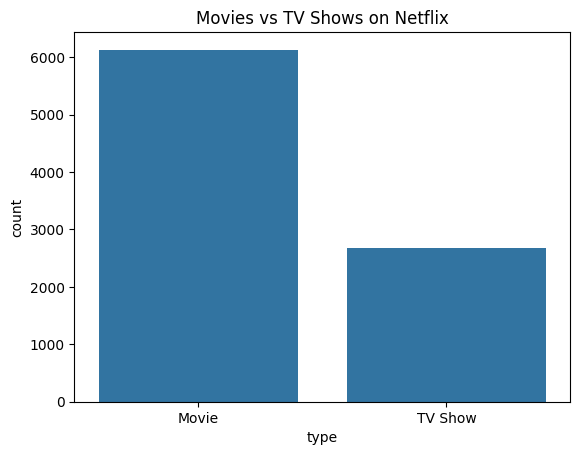

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='type')

plt.title("Movies vs TV Shows on Netflix")
plt.show()

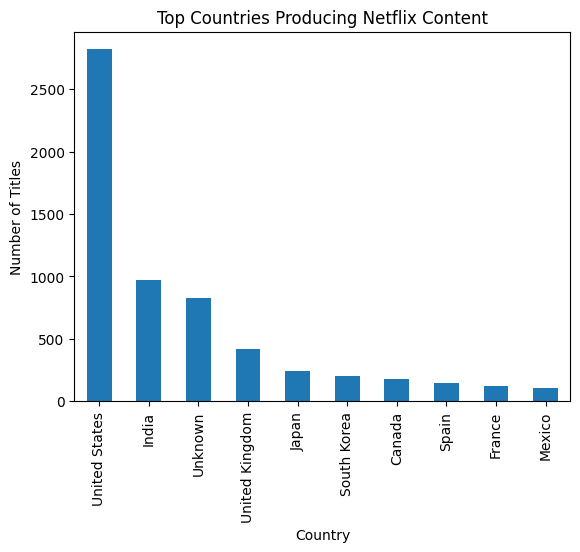

In [30]:
top_countries = df['country'].value_counts().head(10)

top_countries.plot(kind='bar')

plt.title("Top Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.show()

In [31]:
genres = df['listed_in'].str.split(', ', expand=True)

genre_counts = genres.stack().value_counts()

print(genre_counts.head(10))

International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


In [32]:
df.to_csv("cleaned_netflix_data.csv", index=False)

In [33]:
df.to_excel("cleaned_netflix_data.xlsx", index=False)

In [45]:
df.to_csv("netflix_dashboard_data.csv", index=False)

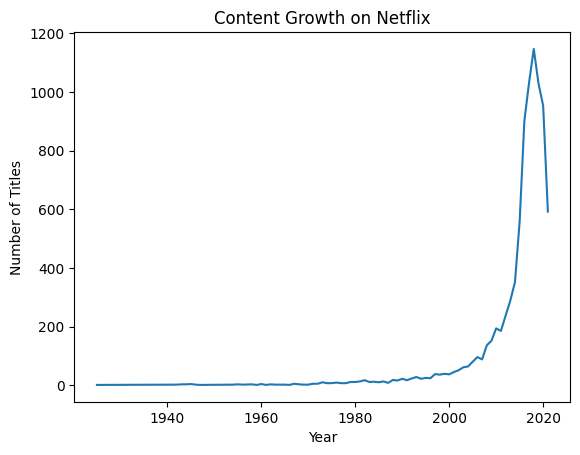

In [46]:
year_data = df.groupby('release_year').size()

year_data.plot()

plt.title("Content Growth on Netflix")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

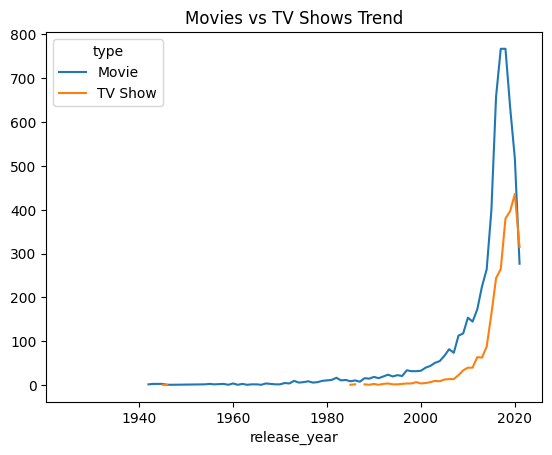

In [47]:
trend = df.groupby(['release_year','type']).size().unstack()

trend.plot()

plt.title("Movies vs TV Shows Trend")
plt.show()

In [48]:
df.describe().to_csv("netflix_summary_statistics.csv")